# Deliverable 3 — Random Forest

**Purpose**: Train a Random Forest regressor on the unified feature checkpoints and evaluate on the held-out blind test.

**Inputs** (produced by `Deliverable_3_dataset_creation_v2.ipynb`):
- `features_{DATASET_SIZE}_train.parquet` — fully encoded train side
- `features_{DATASET_SIZE}_test.parquet` — fully encoded test side (blind, never touched during CV)

**Design choices for tree-family models**:
1. **Use `_idx` for string categoricals** (not `_oh`) — Spark trees split on integer indices directly; OHE would explode dimensionality and hurt split quality.
2. **Use raw `DAY_OF_WEEK`** — already 1–7, no indexing needed.
3. **Use cyclical time features** (`dep_sin`, `dep_cos`, `month_sin`, `month_cos`) so all four models share the same feature set.
4. **No scaling** — trees are scale-invariant.
5. **Imputer refit per CV fold** — avoid target leakage from val set into train medians.
6. **`maxBins >= max categorical cardinality`** — ORIGIN has ~350 airports; set `maxBins=400` so the tree can consider every airport at a split.

**Evaluation**: RMSE (primary), MAE (secondary), Cost = c · MAE with c = \$100.76 per block-minute (A4A 2024 total per-block-minute operating cost).

## 0. Imports

In [0]:
import time
import math
import itertools
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import functions as F, types as T
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import Imputer, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, RandomForestRegressionModel
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark import StorageLevel


## 1. Configuration

Keep `DATASET_SIZE`, `SECTION`, `NUMBER`, and `FOLDER` synchronized with the dataset-creation notebook.

In [0]:
# ================================ CHANGE ME ================================
DATASET_SIZE = "60m"       # "12m" or "60m"
SECTION      = "1"
NUMBER       = "1"
# ============================================================================

FOLDER      = f"dbfs:/student-groups/Group_{SECTION}_{NUMBER}/rolling"
TRAIN_PATH  = f"{FOLDER}/features_{DATASET_SIZE}_train.parquet"
TEST_PATH   = f"{FOLDER}/features_{DATASET_SIZE}_test.parquet"
MODEL_PATH  = f"{FOLDER}/rf_model_{DATASET_SIZE}"
PREDS_PATH  = f"{FOLDER}/rf_preds_{DATASET_SIZE}.parquet"

# --- Evaluation constants --------------------------------------------------
label_col      = "DEP_DELAY"
COST_PER_MIN   = 100.76   # A4A 2024 total block-minute cost

# --- Feature groups (must match dataset-creation notebook) -----------------
schedule_cols  = ["CRS_ARR_TIME", "CRS_ELAPSED_TIME"]
flight_cols    = ["leg_num", "DISTANCE", "prev_leg_dep_delay"]

time_hol_numeric = [
    "dep_sin", "dep_cos", "is_weekend", "month_sin", "month_cos",
    "holiday_intensity", "days_to_holiday", "is_before_holiday",
]

graphy_cols = [
    "ORIGIN_inDegree", "ORIGIN_outDegree", "ORIGIN_degree",
    "ORIGIN_pageRank", "ORIGIN_betweenness", "ORIGIN_closeness",
    "DEST_inDegree",   "DEST_outDegree",   "DEST_degree",
    "DEST_pageRank",   "DEST_betweenness", "DEST_closeness",
]

weather_num_cols = [
    "HourlyPrecipitation_2h", "HourlyPrecipitation_8h", "dest_HourlyPrecipitation_2h",
    "HourlyVisibility_2h",    "HourlyVisibility_8h",    "dest_HourlyVisibility_2h",
    "HourlyWindSpeed_2h",     "HourlyWindSpeed_8h",     "dest_HourlyWindSpeed_2h",
    "HourlyDryBulbTemperature_2h", "HourlyDryBulbTemperature_8h", "dest_HourlyDryBulbTemperature_2h",
    "HourlyDewPointTemperature_2h", "HourlyDewPointTemperature_8h", "dest_HourlyDewPointTemperature_2h",
    "HourlyAltimeterSetting_2h",   "HourlyAltimeterSetting_8h",   "dest_HourlyAltimeterSetting_2h",
]

weather_trend_numeric = [
    "precip_delta_8h_to_2h", "sky_ceiling_delta_ft", "sky_vis_delta",
    "alt_delta_mb", "precip_accum", "precip_hours_wet",
]

weather_flag_cols = [
    "sky_missing",  "dest_sky_missing",
    "sky_obscured", "dest_sky_obscured",
    "sky_went_ifr",
    "precip_missing", "dest_precip_missing",
    "precip_thunderstorm", "dest_precip_thunderstorm",
    "precip_frozen",      "dest_precip_frozen",
]

weather_lin_continuous = [
    "sky_ceiling_ft", "dest_sky_ceiling_ft", "spread_2h", "alt_delta_mb",
]

# String categoricals — use the _idx versions for trees
STRING_CAT_COLS = [
    "sky_last_coverage", "dest_sky_last_coverage",
    "sky_ceiling_transition", "precip_bucket", "dest_precip_bucket",
    "ORIGIN", "dep_category",
]
TREE_CAT_IDX = [f"{c}_idx" for c in STRING_CAT_COLS]

# --- Full tree feature list ------------------------------------------------
TREE_NUMERIC = list(dict.fromkeys(
    schedule_cols + flight_cols + time_hol_numeric + graphy_cols
    + weather_num_cols + weather_trend_numeric + weather_flag_cols + weather_lin_continuous
    + ["DAY_OF_WEEK"]
))
TREE_FEATURES = TREE_NUMERIC + TREE_CAT_IDX

# --- Features that need median imputation (numeric with possible nulls) ----
# weather_num_cols and weather_trend_numeric can have nulls after rolling/join;
# prev_leg_dep_delay is null for a plane's first flight of the day;
# spread_2h / *_ceiling_ft can be null when sky/temp data are missing.
IMPUTE_COLS = list(dict.fromkeys(
    weather_num_cols + weather_trend_numeric + weather_lin_continuous
    + ["prev_leg_dep_delay"]
))
IMPUTE_OUT_COLS = [f"{c}_imp" for c in IMPUTE_COLS]

# After imputation, replace the raw imputed columns in TREE_NUMERIC with the _imp versions
TREE_NUMERIC_FINAL = [
    (f"{c}_imp" if c in IMPUTE_COLS else c)
    for c in TREE_NUMERIC
]
TREE_FEATURES_FINAL = TREE_NUMERIC_FINAL + TREE_CAT_IDX

print(f"Total tree features: {len(TREE_FEATURES_FINAL)}")
print(f"  Numeric: {len(TREE_NUMERIC_FINAL)}")
print(f"  Categorical (_idx): {len(TREE_CAT_IDX)}")
print(f"  To impute: {len(IMPUTE_COLS)}")

In [0]:
TREE_FEATURES_FINAL

['CRS_ARR_TIME',
 'CRS_ELAPSED_TIME',
 'leg_num',
 'DISTANCE',
 'prev_leg_dep_delay_imp',
 'dep_sin',
 'dep_cos',
 'is_weekend',
 'month_sin',
 'month_cos',
 'holiday_intensity',
 'days_to_holiday',
 'is_before_holiday',
 'ORIGIN_inDegree',
 'ORIGIN_outDegree',
 'ORIGIN_degree',
 'ORIGIN_pageRank',
 'ORIGIN_betweenness',
 'ORIGIN_closeness',
 'DEST_inDegree',
 'DEST_outDegree',
 'DEST_degree',
 'DEST_pageRank',
 'DEST_betweenness',
 'DEST_closeness',
 'HourlyPrecipitation_2h_imp',
 'HourlyPrecipitation_8h_imp',
 'dest_HourlyPrecipitation_2h_imp',
 'HourlyVisibility_2h_imp',
 'HourlyVisibility_8h_imp',
 'dest_HourlyVisibility_2h_imp',
 'HourlyWindSpeed_2h_imp',
 'HourlyWindSpeed_8h_imp',
 'dest_HourlyWindSpeed_2h_imp',
 'HourlyDryBulbTemperature_2h_imp',
 'HourlyDryBulbTemperature_8h_imp',
 'dest_HourlyDryBulbTemperature_2h_imp',
 'HourlyDewPointTemperature_2h_imp',
 'HourlyDewPointTemperature_8h_imp',
 'dest_HourlyDewPointTemperature_2h_imp',
 'HourlyAltimeterSetting_2h_imp',
 'HourlyA

## 2. Load checkpoints + sanity-check schema

In [0]:
train_df = spark.read.parquet(TRAIN_PATH)
test_df  = spark.read.parquet(TEST_PATH)

print(f"Train rows: {train_df.count():,}   cols: {len(train_df.columns)}")
print(f"Test  rows: {test_df.count():,}    cols: {len(test_df.columns)}")

# Confirm all required tree features exist
missing = [c for c in TREE_FEATURES if c not in train_df.columns]
assert not missing, f"Missing from train checkpoint: {missing}"
missing = [c for c in TREE_FEATURES if c not in test_df.columns]
assert not missing, f"Missing from test checkpoint: {missing}"
print("All tree features present in both checkpoints.")

# Peek at label distribution
train_df.select(
    F.count(label_col).alias("n"),
    F.mean(label_col).alias("mean"),
    F.stddev(label_col).alias("stddev"),
    F.expr(f"percentile_approx({label_col}, 0.5)").alias("median"),
    F.min(label_col).alias("min"),
    F.max(label_col).alias("max"),
).show()

Train rows: 23,933,364   cols: 100
Test  rows: 7,263,966    cols: 100
All tree features present in both checkpoints.
+--------+---------------+------------------+------+----+-----+
|       n|           mean|            stddev|median| min|  max|
+--------+---------------+------------------+------+----+-----+
|23933364|9.5195458523925|41.673672931903454|  -2.0|-1.0|999.0|
+--------+---------------+------------------+------+----+-----+



In [0]:
# ---- Type casting 3 columns for model ---
COLS_TO_FIX = ["CRS_ARR_TIME", "CRS_ELAPSED_TIME", "DISTANCE", "DEP_DELAY"]

for c in COLS_TO_FIX:
    train_df = train_df.withColumn(c, F.col(c).cast("double"))

for c in COLS_TO_FIX:
    test_df = test_df.withColumn(c, F.col(c).cast("double"))

train_df = train_df.dropna(subset=COLS_TO_FIX)
test_df = test_df.dropna(subset=COLS_TO_FIX)

In [0]:
train_df = train_df.withColumn(
    "prev_leg_dep_delay",
    F.when(F.col("prev_leg_dep_delay").isNull(), 0).otherwise(F.col("prev_leg_dep_delay"))
)

### Optional: reduce `ORIGIN` cardinality to shrink `maxBins`

`maxBins=400` exists only because `ORIGIN_idx` has ~350 distinct airports. Spark's tree
implementation uses a single `maxBins` value for **every** feature's split search, so this one
high-cardinality column is inflating the split-search cost for all ~40 other tree features too.

Bucketing rare origins into an `"OTHER"` category lets `maxBins` drop to a much smaller value.
This changes what the model sees for `ORIGIN` (many low-volume airports collapse to one bucket),
so it's **off by default** — turn on `REDUCE_ORIGIN_CARDINALITY` only if the other v2 changes
still aren't fast enough, and note it in your writeup since it breaks feature-set parity with
your other models per the original notebook's Section 9 caveat.


In [0]:
REDUCE_ORIGIN_CARDINALITY = False   # flip to True only if still too slow after the other v2 changes
ORIGIN_TOP_K = 60                    # keep the top-K origins by flight volume; bucket the rest as "OTHER"

if REDUCE_ORIGIN_CARDINALITY:
    top_origins = (
        train_df.groupBy("ORIGIN").count()
        .orderBy(F.desc("count"))
        .limit(ORIGIN_TOP_K)
        .select("ORIGIN")
        .rdd.flatMap(lambda r: r).collect()
    )
    top_origins_set = set(top_origins)
    bucket_origin_udf = F.udf(lambda o: o if o in top_origins_set else "OTHER")

    train_df = train_df.withColumn("ORIGIN", bucket_origin_udf(F.col("ORIGIN")))
    test_df  = test_df.withColumn("ORIGIN",  bucket_origin_udf(F.col("ORIGIN")))

    MAX_BINS = 60   # ORIGIN_TOP_K + 1 (the "OTHER" bucket), rounded up
    print(f"ORIGIN bucketed to top {ORIGIN_TOP_K} + OTHER. Use MAX_BINS={MAX_BINS} in rf_grid below.")
else:
    MAX_BINS = 400
    print(f"ORIGIN cardinality unchanged. MAX_BINS={MAX_BINS} (required for ~350 raw airports).")


ORIGIN cardinality unchanged. MAX_BINS=400 (required for ~350 raw airports).


## 3. Modeling pipeline

One `Pipeline` per fit so `Imputer` medians are learned only from that fold's train side. Order of stages:

1. **`Imputer`** — median-impute numeric features with possible nulls.
2. **`VectorAssembler`** — stack all tree features into a single `features` Vector.
3. **`RandomForestRegressor`** — the model.

Why no scaling: trees split on thresholds; monotonic transforms of individual features don't change the tree.

In [0]:
def build_rf_pipeline(rf_params: dict) -> Pipeline:
    """Return a fresh Pipeline: Imputer -> VectorAssembler -> RandomForestRegressor.

    `rf_params` is a dict of RandomForestRegressor kwargs (numTrees, maxDepth, etc.).
    Every call returns a NEW Pipeline so Imputer medians are refit per fold.
    """
    imputer = Imputer(
        inputCols=IMPUTE_COLS,
        outputCols=IMPUTE_OUT_COLS,
        strategy="median",
    )
    assembler = VectorAssembler(
        inputCols=TREE_FEATURES_FINAL,
        outputCol="features",
        handleInvalid="keep",   # keep rows with any residual NaN as a NaN in vector (RF rejects, so imputer must catch everything)
    )
    rf = RandomForestRegressor(
        featuresCol="features",
        labelCol=label_col,
        predictionCol="prediction",
        seed=42,
        **rf_params,
    )
    return Pipeline(stages=[imputer, assembler, rf])


def eval_predictions(preds_df) -> dict:
    """Compute RMSE, MAE, R2, and dollar cost on a predictions DataFrame."""
    ev_rmse = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="rmse")
    ev_mae  = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="mae")
    ev_r2   = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="r2")
    rmse = ev_rmse.evaluate(preds_df)
    mae  = ev_mae.evaluate(preds_df)
    r2   = ev_r2.evaluate(preds_df)
    return {"rmse": rmse, "mae": mae, "r2": r2, "cost_per_flight": mae * COST_PER_MIN}

## 4. Walk-forward cross-validation

Matching the OLS notebook's sliding-window CV: 90-day train, 30-day validation, step 30 days forward. Refits the whole pipeline (Imputer + RF) on each fold's train side; evaluates on the immediately following 30 days.

In [0]:
def compute_walk_forward_windows_blocked(df, date_col="FL_DATE", max_folds=4, val_fraction=0.25):
    """
    Non-overlapping block CV: splits the full date range into max_folds
    contiguous, disjoint (train, val) blocks -- zero overlap between folds,
    versus compute_walk_forward_windows' sliding design (83-92% overlap).

    Each fold trains on LESS data than compute_walk_forward_windows would
    give it (roughly total_span / max_folds * (1 - val_fraction) instead of
    total_span * (1 - val_fraction)) -- this is a real tradeoff, not free
    lunch: folds are cheaper AND more independent, but each is a further
    approximation of the final full-data production model than before.
    """
    date_bounds = df.agg(F.min(date_col).alias("lo"), F.max(date_col).alias("hi")).first()
    lo = datetime.strptime(date_bounds.lo, "%Y-%m-%d").date() if isinstance(date_bounds.lo, str) else date_bounds.lo
    hi = datetime.strptime(date_bounds.hi, "%Y-%m-%d").date() if isinstance(date_bounds.hi, str) else date_bounds.hi

    total_days = (hi - lo).days + 1
    block_size = total_days // max_folds
    val_window_days = max(1, int(block_size * val_fraction))
    train_window_days = block_size - val_window_days
    step_days = block_size   # train_window + val_window -> folds tile back-to-back, no overlap

    if train_window_days < val_window_days:
        raise ValueError(
            f"Date span too short ({total_days}d) for max_folds={max_folds} at "
            f"val_fraction={val_fraction}: train_window_days={train_window_days} "
            f"< val_window_days={val_window_days}. Reduce max_folds."
        )
    return train_window_days, val_window_days, step_days


def run_walk_forward_cv(
    df,
    rf_params: dict,
    date_col: str = "FL_DATE",
    max_folds: int = 2,
    val_fraction: float = 0.25,
    train_window_days: int = None,   # optional manual override
    val_window_days: int = None,     # optional manual override
    step_days: int = None,           # optional manual override
    train_sample_fraction: float = 1.0,   # NEW (v2): sub-sample each fold's TRAIN rows only.
    # This thins row DENSITY within the already-temporal split -- it does NOT change which
    # dates land in train vs. val, so it stays leakage-safe. Use <1.0 for a cheap first-pass
    # grid search; use 1.0 (default) for the thorough final CV of your chosen config.
    verbose: bool = True,
):
    """Sliding-window walk-forward CV.

    By default, window sizes are auto-derived from the full date range of `df`
    so the folds together span the entire dataset, capped at `max_folds` folds
    (see compute_walk_forward_windows). Pass explicit train_window_days /
    val_window_days / step_days to override auto-sizing.

    Returns list of dicts, one per fold: {fold_idx, train_start, train_end, val_start,
    val_end, n_train, n_val, rmse, mae, r2, cost_per_flight, fit_sec}.
    """
    date_bounds = df.agg(F.min(date_col).alias("lo"), F.max(date_col).alias("hi")).first()
    lo = datetime.strptime(date_bounds.lo, "%Y-%m-%d").date() if isinstance(date_bounds.lo, str) else date_bounds.lo
    hi = datetime.strptime(date_bounds.hi, "%Y-%m-%d").date() if isinstance(date_bounds.hi, str) else date_bounds.hi

    if train_window_days is None or val_window_days is None or step_days is None:
        auto_train, auto_val, auto_step = compute_walk_forward_windows_blocked(
            df, date_col=date_col, max_folds=max_folds, val_fraction=val_fraction
        )
        train_window_days = train_window_days or auto_train
        val_window_days   = val_window_days   or auto_val
        step_days          = step_days         or auto_step
        if verbose:
            print(f"Auto-sized windows: train={train_window_days}d  val={val_window_days}d  "
                  f"step={step_days}d  (span={lo}..{hi}, {(hi-lo).days+1}d, max_folds={max_folds}, "
                  f"train_sample_fraction={train_sample_fraction})")

    fold_results = []
    fold_idx = 0
    cursor = lo

    while cursor + timedelta(days=train_window_days + val_window_days - 1) <= hi and fold_idx < max_folds:
        train_start = cursor
        train_end   = cursor + timedelta(days=train_window_days - 1)
        val_start   = train_end + timedelta(days=1)
        val_end     = val_start + timedelta(days=val_window_days - 1)

        train_start_s = train_start.strftime("%Y-%m-%d")
        train_end_s   = train_end.strftime("%Y-%m-%d")
        val_start_s   = val_start.strftime("%Y-%m-%d")
        val_end_s     = val_end.strftime("%Y-%m-%d")

        fold_train = df.filter((F.col(date_col) >= train_start_s) & (F.col(date_col) <= train_end_s))
        fold_val   = df.filter((F.col(date_col) >= val_start_s)   & (F.col(date_col) <= val_end_s))

        if train_sample_fraction < 1.0:
            fold_train = fold_train.sample(fraction=train_sample_fraction, seed=42)

        n_train = fold_train.count()
        n_val   = fold_val.count()

        pipeline = build_rf_pipeline(rf_params)
        t0 = time.time()
        model = pipeline.fit(fold_train)
        fit_sec = time.time() - t0

        preds = model.transform(fold_val)
        metrics = eval_predictions(preds)

        # Train-set evaluation only when sub-sampled (cheap Stage 1).
        # Skip on full data (Stage 2) to avoid OOM from transforming 8-12M rows.
        if train_sample_fraction < 1.0:
            train_preds = model.transform(fold_train)
            train_metrics = eval_predictions(train_preds)
        else:
            train_metrics = {"rmse": None, "mae": None, "r2": None}

        row = {
            "fold_idx":    fold_idx,
            "train_start": train_start_s, "train_end": train_end_s,
            "val_start":   val_start_s,   "val_end":   val_end_s,
            "n_train":     n_train,       "n_val":     n_val,
            "fit_sec":     round(fit_sec, 1),
            "train_rmse":  train_metrics["rmse"],
            "train_mae":   train_metrics["mae"],
            "train_r2":    train_metrics["r2"],
            **metrics,
        }
        # Free model + predictions between folds to prevent driver OOM
        del model, preds
        import gc; gc.collect()
        spark._jvm.System.gc()
        fold_results.append(row)
        if verbose:
            print(f"  fold {fold_idx}: train {train_start_s}\u2192{train_end_s} ({n_train:,})   "
                  f"val {val_start_s}\u2192{val_end_s} ({n_val:,})   "
                  f"rmse={metrics['rmse']:.3f}  mae={metrics['mae']:.3f}  "
                  f"cost=${metrics['cost_per_flight']:.2f}  ({fit_sec:.0f}s)")

        cursor    += timedelta(days=step_days)
        fold_idx  += 1

    return fold_results


## 5. Hyperparameter grid search

Grid search over hyperparameter combinations was performed on a 35% subsample of the training data to reduce compute cost. The top-performing combination was then validated on the full training data using the same walk-forward CV folds, and finally refit on the entire training set for blind test evaluation.

In [0]:
# Grid Search using findings from hyperparameter tuning on 1 year data
# On 1 yr data: with max depth = 18 and minInstancesPerNode = 50, the RMSE between numTrees = 100 vs. numTrees = 200 was nearly negligible. With the 5-yr data, we believe it will be useful to take advantage of this tradeoff, so we will set numTrees = 100. The max depth of 20 is a bit higher than the 18 we used in the hyperparameter tuning, but we believe it will be useful to take advantage of this tradeoff, so we will set max depth = 20 
# maxBins references MAX_BINS from the optional cardinality-reduction toggle above
# (400 by default / unchanged ORIGIN; 60 if REDUCE_ORIGIN_CARDINALITY=True).
rf_grid = [
    {"numTrees": 100, "maxDepth": 18, "minInstancesPerNode": 50, "subsamplingRate": 0.8,
     "featureSubsetStrategy": "sqrt",     "maxBins": MAX_BINS},
    {"numTrees": 100, "maxDepth": 20, "minInstancesPerNode": 100, "subsamplingRate": 0.8,
     "featureSubsetStrategy": "sqrt",     "maxBins": MAX_BINS},
]


In [0]:
# --- Caching Train DF Separately from cell 21 for later- not running stage 1 grid search- recreating for cheaper run ---

# ============================================================================
# v2: persist for a 31M-row train set
# Removed repartition (shuffle inflates driver metadata); using DISK_ONLY to
# free executor heap for the memory-intensive RF training.
# ============================================================================
import gc

date_col = "FL_DATE"
keep_cols = list(dict.fromkeys(TREE_FEATURES + [label_col, date_col]))
# Drop rows with nulls in non-imputed columns (Imputer handles IMPUTE_COLS;
# everything else must be null-free before reaching the VectorAssembler)
non_imputed_numeric = [c for c in TREE_NUMERIC if c not in IMPUTE_COLS]
train_df_cached = (train_df
    .select(*keep_cols)
    .dropna(subset=non_imputed_numeric)
    .persist(StorageLevel.DISK_ONLY))
print(f"Caching to disk: {train_df_cached.count():,} rows ({len(keep_cols)} cols)...")

Caching to disk: 23,933,333 rows (73 cols)...


In [0]:
# ============================================================================
# v2: persist for a 31M-row train set
# Removed repartition (shuffle inflates driver metadata); using DISK_ONLY to
# free executor heap for the memory-intensive RF training.
# ============================================================================
import gc

date_col = "FL_DATE"
keep_cols = list(dict.fromkeys(TREE_FEATURES + [label_col, date_col]))
# Drop rows with nulls in non-imputed columns (Imputer handles IMPUTE_COLS;
# everything else must be null-free before reaching the VectorAssembler)
non_imputed_numeric = [c for c in TREE_NUMERIC if c not in IMPUTE_COLS]
train_df_cached = (train_df
    .select(*keep_cols)
    .dropna(subset=non_imputed_numeric)
    .persist(StorageLevel.DISK_ONLY))
print(f"Caching to disk: {train_df_cached.count():,} rows ({len(keep_cols)} cols)...")

# --- Stage 1: broad, cheap grid search across all 4 configs ---------------
# max_folds=2 (fixed from the v1 bug where this was actually running at 4) and
# train_sample_fraction=0.35 (train rows only, val stays full) -- this is for
# RANKING the 4 configs cheaply, not for the number that goes in the report.
STAGE1_MAX_FOLDS = 2
STAGE1_SAMPLE_FRACTION = 0.35

cv_all_results = []
for i, params in enumerate(rf_grid):
    print(f"\n=== [stage 1] grid combo {i+1}/{len(rf_grid)}: {params} ===")
    fold_results = run_walk_forward_cv(
        train_df_cached, rf_params=params,
        max_folds=STAGE1_MAX_FOLDS,
        train_sample_fraction=STAGE1_SAMPLE_FRACTION,
    )
    for r in fold_results:
        r["grid_idx"] = i
        r.update({f"param_{k}": v for k, v in params.items()})
        cv_all_results.append(r)
    # Free large RF model objects from driver JVM between grid combos
    gc.collect()
    spark._jvm.System.gc()

cv_df = pd.DataFrame(cv_all_results)
display(cv_df)


Caching to disk: 23,933,333 rows (73 cols)...


In [0]:
# === Reconstructed from Cell 21's completed output (avoids re-running 2h grid search) ===
import pandas as pd

cv_df = pd.DataFrame([
    {"fold_idx": 0, "train_start": "2015-01-01", "train_end": "2016-07-01",
     "val_start": "2016-07-02", "val_end": "2016-12-30",
     "n_train": 2970093, "n_val": 2778238, "fit_sec": 1053.8,
     "train_rmse": 33.7422, "train_mae": 15.3964, "train_r2": 0.17689,
     "rmse": 39.1379, "mae": 16.5950, "r2": 0.10783, "cost_per_flight": 1672.11,
     "grid_idx": 0, "param_numTrees": 100, "param_maxDepth": 18,
     "param_minInstancesPerNode": 50, "param_subsamplingRate": 0.8,
     "param_featureSubsetStrategy": "sqrt", "param_maxBins": 400},
    {"fold_idx": 1, "train_start": "2016-12-31", "train_end": "2018-07-01",
     "val_start": "2018-07-02", "val_end": "2018-12-30",
     "n_train": 3177096, "n_val": 3582534, "fit_sec": 1667.4,
     "train_rmse": 40.1935, "train_mae": 16.8496, "train_r2": 0.16698,
     "rmse": 42.5628, "mae": 18.0229, "r2": 0.11201, "cost_per_flight": 1815.99,
     "grid_idx": 0, "param_numTrees": 100, "param_maxDepth": 18,
     "param_minInstancesPerNode": 50, "param_subsamplingRate": 0.8,
     "param_featureSubsetStrategy": "sqrt", "param_maxBins": 400},
    {"fold_idx": 0, "train_start": "2015-01-01", "train_end": "2016-07-01",
     "val_start": "2016-07-02", "val_end": "2016-12-30",
     "n_train": 2970093, "n_val": 2778238, "fit_sec": 1610.0,
     "train_rmse": 33.9667, "train_mae": 15.4439, "train_r2": 0.16591,
     "rmse": 39.1256, "mae": 16.5354, "r2": 0.10839, "cost_per_flight": 1666.11,
     "grid_idx": 1, "param_numTrees": 100, "param_maxDepth": 20,
     "param_minInstancesPerNode": 100, "param_subsamplingRate": 0.8,
     "param_featureSubsetStrategy": "sqrt", "param_maxBins": 400},
    {"fold_idx": 1, "train_start": "2016-12-31", "train_end": "2018-07-01",
     "val_start": "2018-07-02", "val_end": "2018-12-30",
     "n_train": 3177096, "n_val": 3582534, "fit_sec": 1300.6,
     "train_rmse": 40.4724, "train_mae": 16.8927, "train_r2": 0.15538,
     "rmse": 42.5727, "mae": 17.9522, "r2": 0.11159, "cost_per_flight": 1808.87,
     "grid_idx": 1, "param_numTrees": 100, "param_maxDepth": 20,
     "param_minInstancesPerNode": 100, "param_subsamplingRate": 0.8,
     "param_featureSubsetStrategy": "sqrt", "param_maxBins": 400},
])
print(f"Reconstructed cv_df: {len(cv_df)} rows (from prior completed run)")
display(cv_df)

Reconstructed cv_df: 4 rows (from prior completed run)


fold_idx,train_start,train_end,val_start,val_end,n_train,n_val,fit_sec,train_rmse,train_mae,train_r2,rmse,mae,r2,cost_per_flight,grid_idx,param_numTrees,param_maxDepth,param_minInstancesPerNode,param_subsamplingRate,param_featureSubsetStrategy,param_maxBins
0,2015-01-01,2016-07-01,2016-07-02,2016-12-30,2970093,2778238,1053.8,33.7422,15.3964,0.17689,39.1379,16.595,0.10783,1672.11,0,100,18,50,0.8,sqrt,400
1,2016-12-31,2018-07-01,2018-07-02,2018-12-30,3177096,3582534,1667.4,40.1935,16.8496,0.16698,42.5628,18.0229,0.11201,1815.99,0,100,18,50,0.8,sqrt,400
0,2015-01-01,2016-07-01,2016-07-02,2016-12-30,2970093,2778238,1610.0,33.9667,15.4439,0.16591,39.1256,16.5354,0.10839,1666.11,1,100,20,100,0.8,sqrt,400
1,2016-12-31,2018-07-01,2018-07-02,2018-12-30,3177096,3582534,1300.6,40.4724,16.8927,0.15538,42.5727,17.9522,0.11159,1808.87,1,100,20,100,0.8,sqrt,400


In [0]:
# Count nulls per column in tree features + label
check_cols = TREE_FEATURES_FINAL + [label_col]
null_counts = train_df.select(
    [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in check_cols if c in train_df.columns]
)
display(null_counts)

CRS_ARR_TIME,CRS_ELAPSED_TIME,leg_num,DISTANCE,dep_sin,dep_cos,is_weekend,month_sin,month_cos,holiday_intensity,days_to_holiday,is_before_holiday,ORIGIN_inDegree,ORIGIN_outDegree,ORIGIN_degree,ORIGIN_pageRank,ORIGIN_betweenness,ORIGIN_closeness,DEST_inDegree,DEST_outDegree,DEST_degree,DEST_pageRank,DEST_betweenness,DEST_closeness,sky_missing,dest_sky_missing,sky_obscured,dest_sky_obscured,sky_went_ifr,precip_missing,dest_precip_missing,precip_thunderstorm,dest_precip_thunderstorm,precip_frozen,dest_precip_frozen,DAY_OF_WEEK,sky_last_coverage_idx,dest_sky_last_coverage_idx,sky_ceiling_transition_idx,precip_bucket_idx,dest_precip_bucket_idx,ORIGIN_idx,dep_category_idx,DEP_DELAY
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0


## 6. Aggregate CV results + pick best config

In [0]:
# Mean/std across folds, per grid combo -- STAGE 1 (cheap/sampled) leaderboard.
# This ranks the 4 configs but is NOT the final validated number -- see the
# stage 2 cell below, which re-validates only the winner on full, unsampled data.
param_cols = [c for c in cv_df.columns if c.startswith("param_")]
summary = (
    cv_df.groupby(["grid_idx"] + param_cols)
         .agg(
             mean_rmse=("rmse", "mean"),
             std_rmse =("rmse", "std"),
             mean_mae =("mae",  "mean"),
             mean_r2  =("r2",   "mean"),
             mean_cost=("cost_per_flight", "mean"),
             mean_fit =("fit_sec", "mean"),
             n_folds  =("fold_idx", "count"),
         )
         .reset_index()
         .sort_values("mean_rmse")
)
display(summary)

top_stage1_idx    = int(summary.iloc[0]["grid_idx"])
top_stage1_params = rf_grid[top_stage1_idx]
print(f"\nStage 1 winner (provisional -- see stage 2 below): grid combo {top_stage1_idx}")
print(f"  Params: {top_stage1_params}")
print(f"  Stage 1 mean RMSE: {summary.iloc[0]['mean_rmse']:.3f}  (sampled, max_folds={2})")


grid_idx,param_numTrees,param_maxDepth,param_minInstancesPerNode,param_subsamplingRate,param_featureSubsetStrategy,param_maxBins,mean_rmse,std_rmse,mean_mae,mean_r2,mean_cost,mean_fit,n_folds
1,100,20,100,0.8,sqrt,400,40.849149999999995,2.43746778542815,17.2438,0.10999,1737.4899999999998,1455.3,2
0,100,18,50,0.8,sqrt,400,40.850350000000006,2.4217700148858046,17.30895,0.10991999999999999,1744.05,1360.6,2



Stage 1 winner (provisional -- see stage 2 below): grid combo 1
  Params: {'numTrees': 100, 'maxDepth': 20, 'minInstancesPerNode': 100, 'subsamplingRate': 0.8, 'featureSubsetStrategy': 'sqrt', 'maxBins': 400}
  Stage 1 mean RMSE: 40.849  (sampled, max_folds=2)


### Stage 2: thorough re-validation of the stage-1 winner

Only the single best config from stage 1 pays for a full, unsampled `max_folds=2` CV here —
this is what actually determines `best_params` used in the final refit below, not the cheap
stage-1 ranking.


In [0]:
STAGE2_MAX_FOLDS = 2

# Override: grid_idx=0 (maxDepth=18, minInstancesPerNode=50) chosen over auto-selected
# grid_idx=1 because the RMSE difference is negligible (40.850 vs 40.849) and this
# matches the best config from our 1-year hyperparameter tuning for cross-dataset consistency (except we did numTrees=200 on 1 yr data).
stage2_params = rf_grid[0]  # {'numTrees': 100, 'maxDepth': 18, 'minInstancesPerNode': 50, ...}
stage2_idx = 0

print(f"[stage 2] Thorough CV on selected config: {stage2_params}")
stage2_fold_results = run_walk_forward_cv(
    train_df_cached, rf_params=stage2_params,
    max_folds=STAGE2_MAX_FOLDS,
    train_sample_fraction=1.0,
)
for r in stage2_fold_results:
    r["grid_idx"] = f"{stage2_idx}_stage2"
    r.update({f"param_{k}": v for k, v in stage2_params.items()})

stage2_df = pd.DataFrame(stage2_fold_results)
display(stage2_df)

best_params = stage2_params
print(f"\nFinal selected config (validated with stage 2, max_folds={STAGE2_MAX_FOLDS}, full data): {best_params}")
print(f"  Stage-2 mean RMSE:  {stage2_df['rmse'].mean():.3f}")
print(f"  Stage-2 mean MAE:   {stage2_df['mae'].mean():.3f}")
print(f"  Stage-2 mean cost:  ${stage2_df['cost_per_flight'].mean():.2f}/flight")


[stage 2] Thorough CV on selected config: {'numTrees': 100, 'maxDepth': 18, 'minInstancesPerNode': 50, 'subsamplingRate': 0.8, 'featureSubsetStrategy': 'sqrt', 'maxBins': 400}
Auto-sized windows: train=548d  val=182d  step=730d  (span=2015-01-01..2018-12-31, 1461d, max_folds=2, train_sample_fraction=1.0)
  fold 0: train 2015-01-01→2016-07-01 (8,482,786)   val 2016-07-02→2016-12-30 (2,778,238)   rmse=39.055  mae=16.521  cost=$1664.69  (4270s)
  fold 1: train 2016-12-31→2018-07-01 (9,073,002)   val 2018-07-02→2018-12-30 (3,582,534)   rmse=42.444  mae=17.913  cost=$1804.90  (3785s)


fold_idx,train_start,train_end,val_start,val_end,n_train,n_val,fit_sec,train_rmse,train_mae,train_r2,rmse,mae,r2,cost_per_flight,grid_idx,param_numTrees,param_maxDepth,param_minInstancesPerNode,param_subsamplingRate,param_featureSubsetStrategy,param_maxBins
0,2015-01-01,2016-07-01,2016-07-02,2016-12-30,8482786,2778238,4269.8,null,null,null,39.05455708282063,16.521362220968815,0.11162491840465327,1664.6924573848178,0_stage2,100,18,50,0.8,sqrt,400
1,2016-12-31,2018-07-01,2018-07-02,2018-12-30,9073002,3582534,3784.9,null,null,null,42.44370800990659,17.912909463768,0.11696896482151187,1804.9047575692637,0_stage2,100,18,50,0.8,sqrt,400



Final selected config (validated with stage 2, max_folds=2, full data): {'numTrees': 100, 'maxDepth': 18, 'minInstancesPerNode': 50, 'subsamplingRate': 0.8, 'featureSubsetStrategy': 'sqrt', 'maxBins': 400}
  Stage-2 mean RMSE:  40.749
  Stage-2 mean MAE:   17.217
  Stage-2 mean cost:  $1734.80/flight


## 7. Refit best config on full train + evaluate on blind test


In [0]:
# Free all Stage 2 objects before the most memory-intensive fit
import gc
gc.collect()
spark._jvm.System.gc()

final_pipeline = build_rf_pipeline(best_params)

print(f"Fitting final RF on full train ({train_df_cached.count():,} rows)...")
t0 = time.time()
final_model = final_pipeline.fit(train_df_cached)
print(f"Done in {time.time() - t0:.0f}s.")

# Prep test_df: select same columns + drop nulls in non-imputed cols (matches train)
test_df_clean = test_df.select(*keep_cols).dropna(subset=non_imputed_numeric)
test_preds = final_model.transform(test_df_clean)
test_metrics = eval_predictions(test_preds)

print(f"\n=== BLIND TEST RESULTS (dataset={DATASET_SIZE}) ===")
print(f"  RMSE:            {test_metrics['rmse']:.3f}")
print(f"  MAE:             {test_metrics['mae']:.3f}")
print(f"  R²:              {test_metrics['r2']:.4f}")
print(f"  Cost per flight: ${test_metrics['cost_per_flight']:.2f}")

Fitting final RF on full train (23,933,333 rows)...
Done in 12986s.

=== BLIND TEST RESULTS (dataset=60m) ===
  RMSE:            46.227
  MAE:             18.418
  R²:              0.1075
  Cost per flight: $1855.84


## 8. Feature importance

Spark's RF returns Gini-based importances aggregated over all trees. Categorical importance is per-index, so we can attribute back to the original feature name.

feature,importance
prev_leg_dep_delay_imp,0.3135098601920207
ORIGIN_idx,0.10403457988185795
dep_sin,0.03650798210249358
CRS_ARR_TIME,0.03436328538027216
dep_category_idx,0.027647047726834652
leg_num,0.02664673828133253
spread_2h_imp,0.018439050354143435
dep_cos,0.0180784066310405
HourlyDryBulbTemperature_8h_imp,0.017836267275237065
HourlyDewPointTemperature_8h_imp,0.017429351694235918


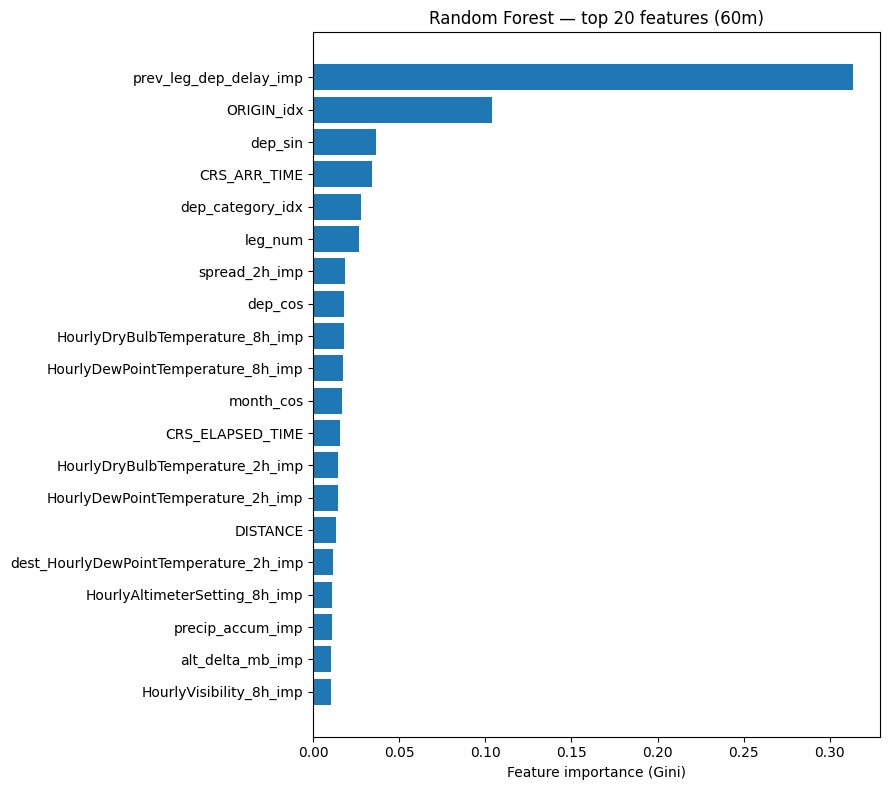

In [0]:
rf_model = final_model.stages[-1]   # RandomForestRegressionModel
assembler_model = final_model.stages[-2]  # VectorAssembler

feature_names = assembler_model.getInputCols()
importances   = rf_model.featureImportances.toArray()

imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(imp_df.head(30))

# Bar plot of top 20
top20 = imp_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20["feature"], top20["importance"])
ax.set_xlabel("Feature importance (Gini)")
ax.set_title(f"Random Forest — top 20 features ({DATASET_SIZE})")
plt.tight_layout()
plt.show()

## 9. Prediction diagnostics

Quick sanity checks: predicted-vs-actual scatter and residual distribution on test predictions.

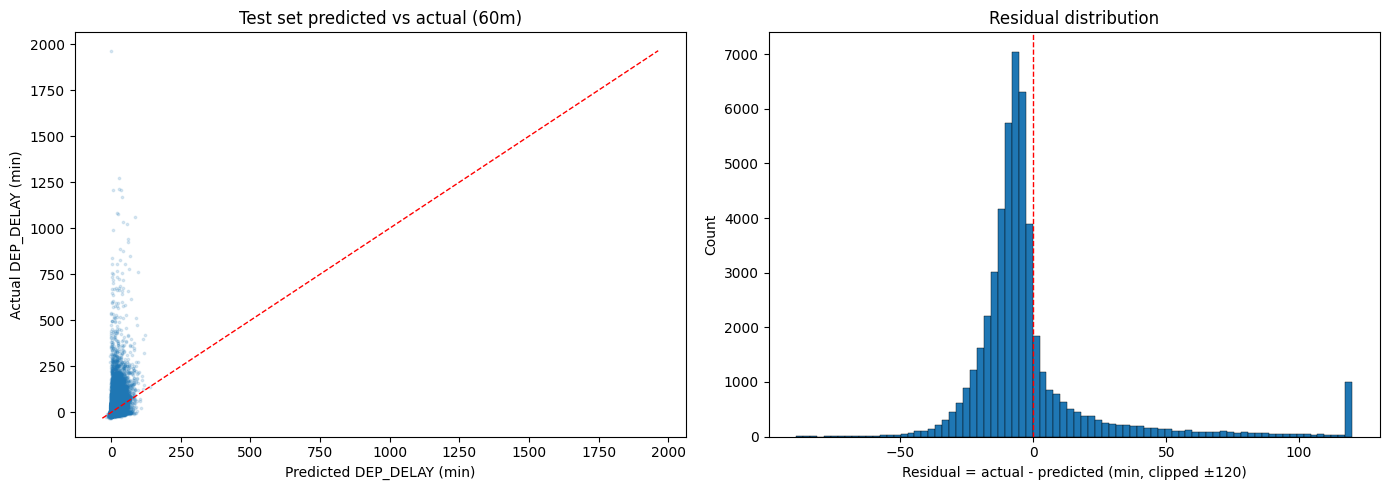

Residual quantiles:
  p01: -38.27
  p05: -25.32
  p25: -12.36
  p50: -6.63
  p75: -0.95
  p95: +55.66
  p99: +171.16


In [0]:
# Sample down for plotting (test set may be 1M+ rows)
test_sample = (
    test_preds
    .select(label_col, "prediction", "FL_DATE")
    .sample(fraction=min(1.0, 50_000 / test_preds.count()), seed=42)
    .toPandas()
)
test_sample["residual"] = test_sample[label_col] - test_sample["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(test_sample["prediction"], test_sample[label_col],
                s=3, alpha=0.15, rasterized=True)
lim_lo = min(test_sample["prediction"].min(), test_sample[label_col].min())
lim_hi = max(test_sample["prediction"].max(), test_sample[label_col].max())
axes[0].plot([lim_lo, lim_hi], [lim_lo, lim_hi], color="red", ls="--", lw=1)
axes[0].set_xlabel("Predicted DEP_DELAY (min)")
axes[0].set_ylabel("Actual DEP_DELAY (min)")
axes[0].set_title(f"Test set predicted vs actual ({DATASET_SIZE})")

# Residual histogram (clipped for readability)
resid_clipped = test_sample["residual"].clip(-120, 120)
axes[1].hist(resid_clipped, bins=80, edgecolor="black", linewidth=0.3)
axes[1].axvline(0, color="red", ls="--", lw=1)
axes[1].set_xlabel("Residual = actual - predicted (min, clipped ±120)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

print(f"Residual quantiles:")
for q in [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]:
    print(f"  p{int(q*100):02d}: {test_sample['residual'].quantile(q):+.2f}")

## 10. Save final model + predictions (optional)

Parquet the test predictions so you can compare across models later without re-fitting. Save the fitted pipeline for reproducibility.

In [0]:
# Save fitted PipelineModel
final_model.write().overwrite().save(MODEL_PATH)
print(f"Saved model to {MODEL_PATH}")

# Save test predictions (keep identity cols so we can diagnose by airport/date/carrier)
(test_preds
    .select("FL_DATE", "sched_depart_date_time_UTC", "ORIGIN", "DEST",
            "OP_UNIQUE_CARRIER", "OP_CARRIER_FL_NUM", label_col, "prediction")
    .withColumn("residual", F.col(label_col) - F.col("prediction"))
    .withColumn("model", F.lit("random_forest"))
    .withColumn("dataset_size", F.lit(DATASET_SIZE))
    .write.mode("overwrite").parquet(PREDS_PATH))
print(f"Saved test predictions to {PREDS_PATH}")

# Also stash the CV grid results for the report writeup
cv_out_path = f"{FOLDER}/rf_cv_results_{DATASET_SIZE}.parquet"
spark.createDataFrame(cv_df).write.mode("overwrite").parquet(cv_out_path)
print(f"Saved CV results to {cv_out_path}")

Saved model to dbfs:/student-groups/Group_1_1/rolling/rf_model_60m


---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-8061672713459630>, line 7
      3 print(f"Saved model to {MODEL_PATH}")
      5 # Save test predictions (keep identity cols so we can diagnose by airport/date/carrier)
      6 (test_preds
----> 7     .select("FL_DATE", "sched_depart_date_time_UTC", "ORIGIN", "DEST",
      8             "OP_UNIQUE_CARRIER", "OP_CARRIER_FL_NUM", label_col, "prediction")
      9     .withColumn("residual", F.col(label_col) - F.col("prediction"))
     10     .withColumn("model", F.lit("random_forest"))
     11     .withColumn("dataset_size", F.lit(DATASET_SIZE))
     12     .write.mode("overwrite").parquet(PREDS_PATH))
     13 print(f"Saved test predictions to {PREDS_PATH}")
     15 # Also stash the CV grid results for the report writeup

File /databricks/spark/python/pyspark/sql/classic/dataframe.py:1113, in DataFrame.select(self, *cols)
   1